In [1]:
import os

os.chdir('..')
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # set for determinism

## Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [ ]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
from src.model.training import chamfer_hausdorff
import src.loss.SDF_loss as loss
from src.mesh_extraction.marching_cubes_test import write_obj
import src.model.MLP as simple
import src.data.dataset as data
import src.model.pruning_module as pm
import src.model.pruning_module_global as pm_g
import src.mesh_extraction.marching_cubes_gpu as marching_cubes
import random


def set_seeds():
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

mesh = data.MeshDataset('data/pointclouds/Armadillo/Armadillo.ply')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [4]:
size_per_layer = 256
set_seeds()
model_no = si.SIRENSDF()
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=2, lambda_inter=0.75, lambda_off=10, lambda_twd=1e-4, model=model_no)
optimizer = torch.optim.Adam(model_no.parameters(), lr=1e-4)
si.weight_stats(model_no)

Weight statistics per layer:
------------------------------------------------------------
Hidden layer  0
  Weight: mean=7.1341e-03, std=1.8916e-01, min=-3.3078e-01, max=3.3230e-01
  Bias  : mean=-1.2152e-02, std=1.8760e-01, min=-3.2975e-01, max=3.3306e-01
  Omega scale (exp): mean=2.7183e+00, std=0.0000e+00
------------------------------------------------------------
Hidden layer  1
  Weight: mean=6.2948e-06, std=2.9461e-03, min=-5.1030e-03, max=5.1029e-03
  Bias  : mean=3.2051e-05, std=2.9077e-03, min=-5.0769e-03, max=5.0955e-03
------------------------------------------------------------
Hidden layer  2
  Weight: mean=-2.4295e-05, std=2.9552e-03, min=-5.1031e-03, max=5.1029e-03
  Bias  : mean=-4.6270e-05, std=2.9337e-03, min=-5.0569e-03, max=5.1006e-03
------------------------------------------------------------
Hidden layer  3
  Weight: mean=-1.7248e-05, std=2.9479e-03, min=-5.1030e-03, max=5.1028e-03
  Bias  : mean=1.3535e-04, std=2.7929e-03, min=-4.9978e-03, max=5.0838e-03
------

## Model training without pruning or densification



Step 0 | IoU 0.0697 | Loss 6.2043
Step 10 | Loss 0.8888
Step 20 | Loss 0.5654
Step 30 | Loss 0.4127
Step 40 | Loss 0.3142
Step 50 | Loss 0.2542
Step 60 | Loss 0.2152
Step 70 | Loss 0.1817
Step 80 | Loss 0.1539
Step 90 | Loss 0.1408
Step 100 | IoU 0.5096 | Loss 0.1234
Step 110 | Loss 0.1154
Step 120 | Loss 0.1062
Step 130 | Loss 0.0980
Step 140 | Loss 0.0916
Step 150 | Loss 0.0864
Step 160 | Loss 0.0846
Step 170 | Loss 0.0801
Step 180 | Loss 0.0756
Step 190 | Loss 0.0726
Step 200 | IoU 0.8975 | Loss 0.0693
Step 210 | Loss 0.0669
Step 220 | Loss 0.0639
Step 230 | Loss 0.0619
Step 240 | Loss 0.0604
Step 250 | Loss 0.0591
Step 260 | Loss 0.0574
Step 270 | Loss 0.0566
Step 280 | Loss 0.0547
Step 290 | Loss 0.0540
Step 300 | IoU 0.9736 | Loss 0.0541
Step 310 | Loss 0.0526
Step 320 | Loss 0.0518
Step 330 | Loss 0.0507
Step 340 | Loss 0.0488
Step 350 | Loss 0.0488
Step 360 | Loss 0.0492
Step 370 | Loss 0.0484
Step 380 | Loss 0.0468
Step 390 | Loss 0.0470
Step 400 | IoU 0.9830 | Loss 0.0455
Ste

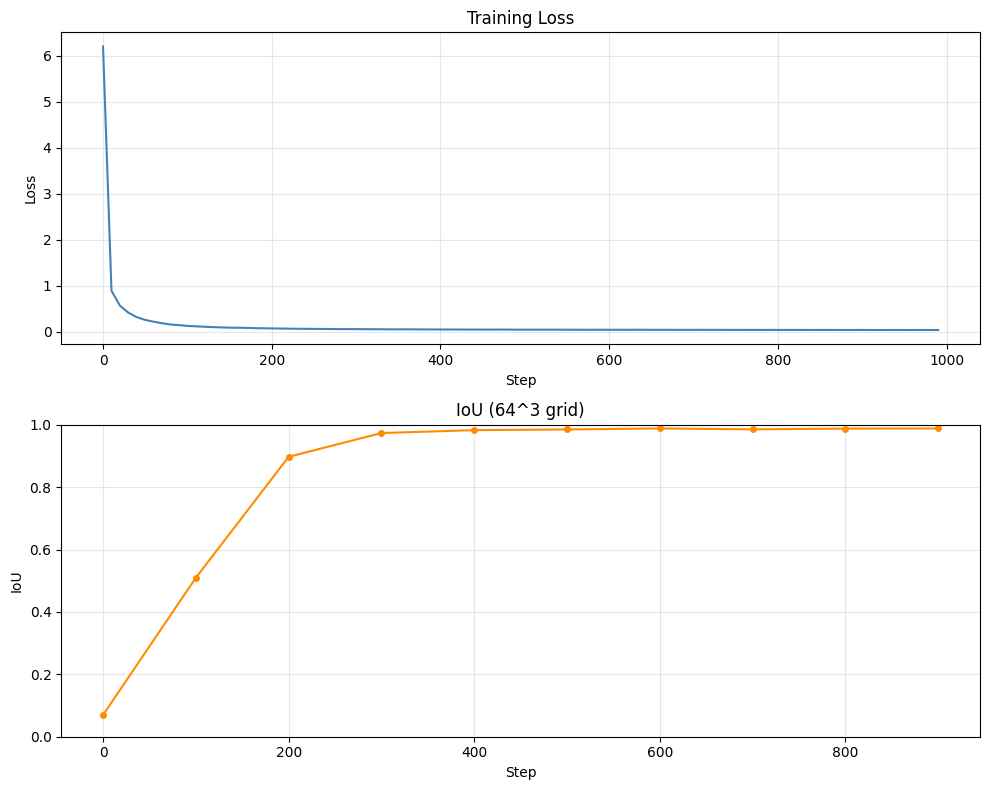

Saved training_curves.png


In [7]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_no, loss=model_loss, optimizer=optimizer, scene=mesh.scene)

#### Model size after pruning

In [ ]:
model_no.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Hidden layer  3:  256 neurons
Hidden layer  4:  256 neurons
Final layer    :    1 neurons


In [8]:
marching_cubes.write_obj("armadillo_128_unpruned.obj", model=model_no, resolution=128, level=0.0)

In [9]:
chamfer, hausdorff = chamfer_hausdorff("armadillo_128_AIRe.obj", "armadillo_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 79527, vertices: 50109
mesh2 triangles: 79112, vertices: 50112
chamfer: 0.0062 | hausdorff: 0.9736


## Model training with densification

In [ ]:
set_seeds()
model_yes = si.SIRENSDF()
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=0.25, lambda_normal=2, lambda_inter=0.05, lambda_off=2, lambda_twd=1e-4, model=model_yes)
optimizer = torch.optim.Adam(model_yes.parameters(), lr=1e-4)
si.weight_stats(model_yes)

Weight statistics per layer:
------------------------------------------------------------
Hidden layer  0
  Weight: mean=7.1341e-03, std=1.8916e-01, min=-3.3078e-01, max=3.3230e-01
  Bias  : mean=-1.2152e-02, std=1.8760e-01, min=-3.2975e-01, max=3.3306e-01
  Omega scale (exp): mean=2.7183e+00, std=0.0000e+00
------------------------------------------------------------
Hidden layer  1
  Weight: mean=6.2948e-06, std=2.9461e-03, min=-5.1030e-03, max=5.1029e-03
  Bias  : mean=3.2051e-05, std=2.9077e-03, min=-5.0769e-03, max=5.0955e-03
------------------------------------------------------------
Hidden layer  2
  Weight: mean=-2.4295e-05, std=2.9552e-03, min=-5.1031e-03, max=5.1029e-03
  Bias  : mean=-4.6270e-05, std=2.9337e-03, min=-5.0569e-03, max=5.1006e-03
------------------------------------------------------------
Hidden layer  3
  Weight: mean=-1.7248e-05, std=2.9479e-03, min=-5.1030e-03, max=5.1028e-03
  Bias  : mean=1.3535e-04, std=2.7929e-03, min=-4.9978e-03, max=5.0838e-03
------

In [ ]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_yes, loss=model_loss, optimizer=optimizer, scene=mesh.scene, densification=True)

Step 0 | Loss 2.5587291717529297
Step 10 | Loss 0.4769289195537567
Step 20 | Loss 0.37794047594070435
Step 30 | Loss 0.33678868412971497
Step 40 | Loss 0.3176746368408203
Step 50 | Loss 0.3009178042411804
Step 60 | Loss 0.2947434186935425
Step 70 | Loss 0.2815569341182709
Step 80 | Loss 0.2748466432094574
Step 90 | Loss 0.2697475552558899
Step 100 | Loss 0.26551488041877747
Step 110 | Loss 0.2625808119773865
Step 120 | Loss 0.25534701347351074
Step 130 | Loss 0.2555489242076874
Step 140 | Loss 0.25084608793258667
Step 150 | Loss 0.25337663292884827
Step 160 | Loss 0.24703876674175262
Step 170 | Loss 0.2359398603439331
Step 180 | Loss 0.24226884543895721
Step 190 | Loss 0.23784910142421722
Added 52 frequencies to the embedding layer.
Step 200 | Loss 0.23929759860038757
Step 210 | Loss 0.295942097902298
Step 220 | Loss 0.2705099284648895
Step 230 | Loss 0.2554838955402374
Step 240 | Loss 0.24585115909576416
Step 250 | Loss 0.23829390108585358
Step 260 | Loss 0.23150791227817535
Step 270 

In [ ]:
model_yes.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  308 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Hidden layer  3:  256 neurons
Hidden layer  4:  256 neurons
Final layer    :    1 neurons


In [ ]:
marching_cubes.write_obj("armadillo_128_densified.obj", model=model_yes, resolution=128, level=0.0)

In [ ]:
device = torch.device("cuda")
z = torch.linspace(-1, 1, 200).to(device)
points = torch.stack([torch.zeros_like(z), torch.zeros_like(z), z], dim=-1)

vals = model_no(points).detach().cpu().numpy()
print(vals)

[[ 0.11615533]
 [ 0.11941325]
 [ 0.11704771]
 [ 0.11075453]
 [ 0.10445689]
 [ 0.10179514]
 [ 0.10292568]
 [ 0.10567626]
 [ 0.10863627]
 [ 0.1085114 ]
 [ 0.10206368]
 [ 0.09301808]
 [ 0.08854083]
 [ 0.09122633]
 [ 0.09673568]
 [ 0.10044038]
 [ 0.10215561]
 [ 0.10439496]
 [ 0.10877287]
 [ 0.11357   ]
 [ 0.11475699]
 [ 0.10903019]
 [ 0.0971089 ]
 [ 0.08283847]
 [ 0.06960293]
 [ 0.0585709 ]
 [ 0.05223446]
 [ 0.05393174]
 [ 0.06162363]
 [ 0.07120408]
 [ 0.08028352]
 [ 0.08897665]
 [ 0.09846274]
 [ 0.10794844]
 [ 0.11525588]
 [ 0.1199657 ]
 [ 0.12224095]
 [ 0.1233822 ]
 [ 0.12385272]
 [ 0.12239403]
 [ 0.11892729]
 [ 0.11432879]
 [ 0.10761803]
 [ 0.09727194]
 [ 0.08541252]
 [ 0.07576196]
 [ 0.06972736]
 [ 0.06720897]
 [ 0.06773502]
 [ 0.07013845]
 [ 0.07213636]
 [ 0.0708369 ]
 [ 0.06630418]
 [ 0.06092894]
 [ 0.058522  ]
 [ 0.05949109]
 [ 0.06129476]
 [ 0.06172143]
 [ 0.06040991]
 [ 0.05936313]
 [ 0.0607148 ]
 [ 0.06468398]
 [ 0.06957204]
 [ 0.07329229]
 [ 0.07338554]
 [ 0.06854447]
 [ 0.06129

## AIRe: Model training (no densification)

In [5]:
set_seeds()
model_aire_no = si.SIRENSDF()
prune_AIRe = pm.AIRe(model_aire_no, 0.6, int(size_per_layer * 0.2))
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=2, lambda_inter=0.75, lambda_off=10, lambda_twd=1e-4, model=model_aire_no, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model_aire_no.parameters(), lr=1e-4)

Step 0 | IoU 0.0695 | Loss 3.7390
Step 10 | Loss 0.7553
Step 20 | Loss 0.4727
Step 30 | Loss 0.3244
Step 40 | Loss 0.2425
Step 50 | Loss 0.2009
Step 60 | Loss 0.1740
Step 70 | Loss 0.1485
Step 80 | Loss 0.1287
Step 90 | Loss 0.1218
Step 100 | IoU 0.6991 | Loss 0.1084
Step 110 | Loss 0.1043
Step 120 | Loss 0.0936
Step 130 | Loss 0.0906
Step 140 | Loss 0.0867
Step 150 | Loss 0.0837
Step 160 | Loss 0.0795
Step 170 | Loss 0.0764
Step 180 | Loss 0.0732
Step 190 | Loss 0.0714
Step 200 | IoU 0.9649 | Loss 0.0699
Step 210 | Loss 0.0675
Step 220 | Loss 0.0666
Step 230 | Loss 0.0657
Step 240 | Loss 0.0648
Step 250 | Loss 0.0618
Step 260 | Loss 0.0618
Step 270 | Loss 0.0610
Step 280 | Loss 0.0588
Step 290 | Loss 0.0606
Step 300 | IoU 0.9798 | Loss 0.0593
Step 310 | Loss 0.0587
Step 320 | Loss 0.0577
Step 330 | Loss 0.0559
Step 340 | Loss 0.0554
Step 350 | Loss 0.0545
Step 360 | Loss 0.0549
Step 370 | Loss 0.0539
Step 380 | Loss 0.0530
Step 390 | Loss 0.0533
Pruned 588 neurons.
Step 400 | IoU 0.08

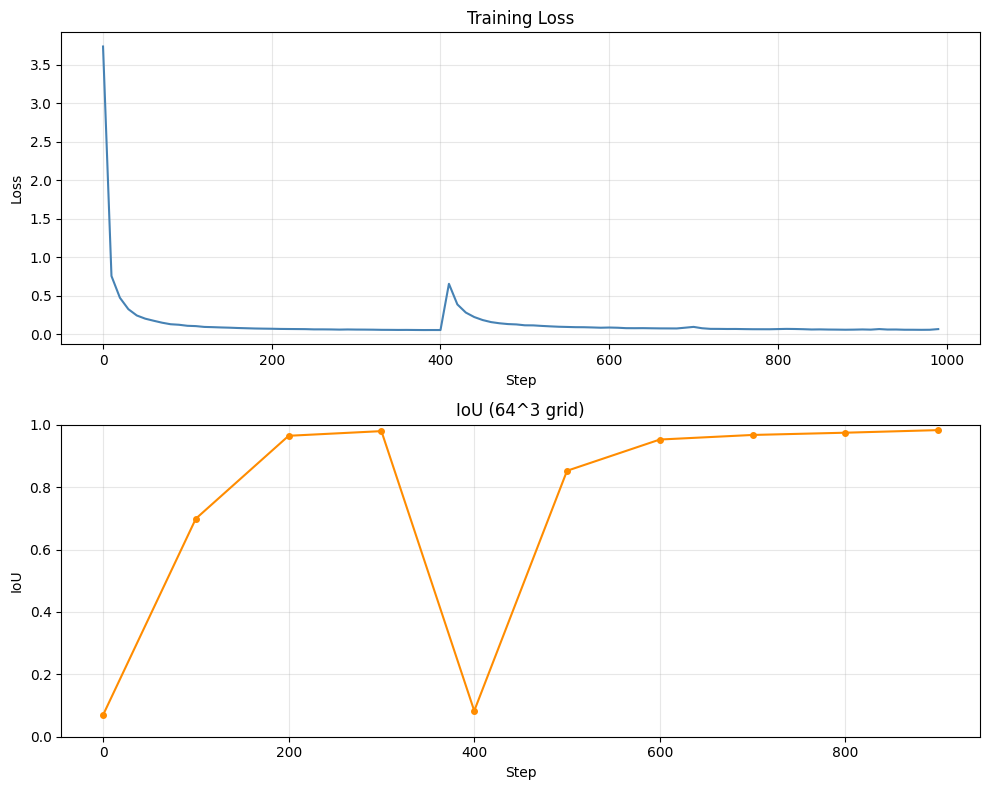

Saved training_curves.png


In [6]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_aire_no, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe)

In [7]:
model_aire_no.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  103 neurons
Hidden layer  2:  120 neurons
Hidden layer  3:  104 neurons
Hidden layer  4:  109 neurons
Final layer    :    1 neurons


In [8]:
marching_cubes.write_obj("armadillo_128_AIRe.obj", model=model_aire_no, resolution=128, level=0.0)

## DepGraph: Model training (no densification)

In [ ]:
set_seeds()
model_dep_no = si.SIRENSDF()
prune_DepGraph = pm.DepGraph(model_dep_no, 0.6, int(size_per_layer * 0.2))
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=0.25, lambda_normal=2, lambda_inter=0.05, lambda_off=2, lambda_twd=1e-4, model=model_dep_no, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model_dep_no.parameters(), lr=1e-4)

In [ ]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_dep_no, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph)

Step 0 | Loss 2.5599801540374756
Step 10 | Loss 0.47809037566185
Step 20 | Loss 0.3789999783039093
Step 30 | Loss 0.33777710795402527
Step 40 | Loss 0.318610280752182
Step 50 | Loss 0.30183839797973633
Step 60 | Loss 0.2956336438655853
Step 70 | Loss 0.28242257237434387
Step 80 | Loss 0.27570125460624695
Step 90 | Loss 0.2705899775028229
Step 100 | Loss 0.2663497030735016
Step 110 | Loss 0.26338595151901245
Step 120 | Loss 0.25615599751472473
Step 130 | Loss 0.25628557801246643
Step 140 | Loss 0.2515798807144165
Step 150 | Loss 0.25408610701560974
Step 160 | Loss 0.24776270985603333
Step 170 | Loss 0.23666636645793915
Step 180 | Loss 0.24300862848758698
Step 190 | Loss 0.23860269784927368
Step 200 | Loss 0.2400287687778473
Step 210 | Loss 0.23971779644489288
Step 220 | Loss 0.23428228497505188
Step 230 | Loss 0.23260390758514404
Step 240 | Loss 0.23160606622695923
Step 250 | Loss 0.22927217185497284
Step 260 | Loss 0.2264605164527893
Step 270 | Loss 0.22785885632038116
Step 280 | Loss 

In [ ]:
model_dep_no.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Hidden layer  3:  102 neurons
Hidden layer  4:  102 neurons
Final layer    :    1 neurons


In [ ]:
marching_cubes.write_obj("armadillo_128_DepGraph.obj", model=model_dep_no, resolution=128, level=0.0)

## AIRe: Model training with densification

In [ ]:
set_seeds()
model_aire_yes = si.SIRENSDF()
prune_AIRe = pm.AIRe(model_aire_yes, 0.6, int(size_per_layer * 0.2))
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=0.25, lambda_normal=2, lambda_inter=0.05, lambda_off=2, lambda_twd=1e-4, model=model_aire_yes, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model_aire_yes.parameters(), lr=1e-4)

In [ ]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_aire_yes, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe, densification=True)

Step 0 | Loss 2.571408987045288
Step 10 | Loss 0.48973679542541504
Step 20 | Loss 0.39074957370758057
Step 30 | Loss 0.34962552785873413
Step 40 | Loss 0.330488920211792
Step 50 | Loss 0.31372010707855225
Step 60 | Loss 0.3075138330459595
Step 70 | Loss 0.2943316400051117
Step 80 | Loss 0.28757527470588684
Step 90 | Loss 0.28246963024139404
Step 100 | Loss 0.27817487716674805
Step 110 | Loss 0.2752159535884857
Step 120 | Loss 0.26794353127479553
Step 130 | Loss 0.2681148052215576
Step 140 | Loss 0.26337018609046936
Step 150 | Loss 0.2657989263534546
Step 160 | Loss 0.2594328820705414
Step 170 | Loss 0.24827778339385986
Step 180 | Loss 0.2545925974845886
Step 190 | Loss 0.2500864267349243
Added 52 frequencies to the embedding layer.
Step 200 | Loss 0.2514670193195343
Step 210 | Loss 0.3059181571006775
Step 220 | Loss 0.2800002992153168
Step 230 | Loss 0.26505109667778015
Step 240 | Loss 0.2552188038825989
Step 250 | Loss 0.24738073348999023
Step 260 | Loss 0.2404773235321045
Step 270 | 

In [ ]:
model_aire_yes.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  308 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Hidden layer  3:  102 neurons
Hidden layer  4:  102 neurons
Final layer    :    1 neurons


In [ ]:
marching_cubes.write_obj("armadillo_128_AIRe_densified.obj", model=model_aire_yes, resolution=128, level=0.0)

## DepGraph: Model training with densification

In [ ]:
set_seeds()
model_dep_yes = si.SIRENSDF()
prune_DepGraph = pm.DepGraph(model_dep_yes, 0.6, int(0.2*size_per_layer))
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=0.25, lambda_normal=2, lambda_inter=0.05, lambda_off=2, lambda_twd=1e-4, model=model_dep_yes, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model_dep_yes.parameters(), lr=1e-4)

In [ ]:
train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model_dep_yes, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph, densification=True)

Step 0 | Loss 2.5599801540374756
Step 10 | Loss 0.47809037566185
Step 20 | Loss 0.3789999783039093
Step 30 | Loss 0.33777710795402527
Step 40 | Loss 0.318610280752182
Step 50 | Loss 0.30183839797973633
Step 60 | Loss 0.2956336438655853
Step 70 | Loss 0.28242257237434387
Step 80 | Loss 0.27570125460624695
Step 90 | Loss 0.2705899775028229
Step 100 | Loss 0.2663497030735016
Step 110 | Loss 0.26338595151901245
Step 120 | Loss 0.25615599751472473
Step 130 | Loss 0.25628557801246643
Step 140 | Loss 0.2515798807144165
Step 150 | Loss 0.25408610701560974
Step 160 | Loss 0.24776270985603333
Step 170 | Loss 0.23666636645793915
Step 180 | Loss 0.24300862848758698
Step 190 | Loss 0.23860269784927368
Added 52 frequencies to the embedding layer.
Step 200 | Loss 0.2400287687778473
Step 210 | Loss 0.29678577184677124
Step 220 | Loss 0.2712213397026062
Step 230 | Loss 0.25614631175994873
Step 240 | Loss 0.24642033874988556
Step 250 | Loss 0.23889096081256866
Step 260 | Loss 0.23209798336029053
Step 27

In [ ]:
model_dep_yes.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  308 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Hidden layer  3:  102 neurons
Hidden layer  4:  102 neurons
Final layer    :    1 neurons


In [ ]:
marching_cubes.write_obj("armadillo_128_DepGraph_densified.obj", model=model_dep_yes, resolution=128, level=0.0)

In [ ]:
#from src.mesh_extraction import marching_cubes_test 
#marching_cubes_test.write_obj("lucy_128_gt.obj", mesh.scene, 128, 0.0)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Sample a few surface points and check their SDF values
test_points = mesh.vertices[:10]  # First 10 points
test_tensor = torch.from_numpy(test_points).float().to(device)
with torch.no_grad():
    sdf_values = model_no(test_tensor)
print("SDF values for surface points:")
print(sdf_values)
print("Mean absolute SDF:", torch.abs(sdf_values).mean().item())

SDF values for surface points:
tensor([[ 2.1020e-05],
        [ 3.4788e-03],
        [-2.3386e-04],
        [ 3.9918e-05],
        [ 4.1725e-03],
        [ 4.5397e-03],
        [ 4.0368e-03],
        [-4.1481e-06],
        [ 1.9721e-03],
        [-3.3731e-03]], device='cuda:0')
Mean absolute SDF: 0.002187199890613556


In [ ]:
# import src.mesh_extraction.marching_cubes_test as marching_cubes_test
# marching_cubes_test.write_obj("armadillo_mesh_ground_truth_128.obj", scene=mesh.scene, resolution=128, level=0.0)


In [ ]:
# Make batched point
device = torch.device("cuda")
test_point = torch.from_numpy(np.array([[-1, -1, -1], [0, 0, 0]])).float().to(device)

# Compute SIREN model prediction
sdf_pred = model_no(test_point)
print("SIREN prediction:", sdf_pred)

# Compute Open3D signed distance
distance = mesh.scene.compute_signed_distance(
    o3d.core.Tensor(test_point.cpu().numpy(), dtype=o3d.core.Dtype.Float32)
)
print("Open3D SDF:", distance.numpy())

SIREN prediction: tensor([[ 0.0224],
        [-0.0486]], device='cuda:0', grad_fn=<AddmmBackward0>)
Open3D SDF: [ 0.96991843 -0.07447068]


In [ ]:
torch.save(model_no.state_dict(), "model_no.pth")
torch.save(model_yes.state_dict(), "model_yes.pth")
torch.save(model_aire_no.state_dict(), "model_aire_no.pth")
torch.save(model_dep_no.state_dict(), "model_dep_no.pth")
torch.save(model_aire_yes.state_dict(), "model_aire_yes.pth")
torch.save(model_dep_yes.state_dict(), "model_dep_yes.pth")

In [ ]:
model = si.SIRENSDF()
model.load_state_dict(torch.load('model_no.pth', weights_only=True))
model.eval()
model.to(device=torch.device("cuda"))


marching_cubes.write_obj("armadillo_256_unpruned.obj", model=model, resolution=256)
